In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load data
path2 = "C:\\Users\\merda\\Downloads\\titanic.csv"
df = pd.read_csv("titanic.csv")
# clean data
df.drop(["PassengerId", "Ticket", 'Cabin'], axis=1, inplace=True)
df.Age = df.Age.fillna(df.Age.median())
df.Embarked = df.Embarked.fillna(df.Embarked.mode()[0])
df.set_index('Name', inplace=True)

In [4]:
male_survival_rate = round(df[df.Sex == "male"].describe().at["mean", "Survived"] * 100, 2)
female_survival_rate = round(df[df.Sex == "female"].describe().at["mean", "Survived"] * 100, 2)
print(f"Male survival rate: {male_survival_rate:.2f}%")
print(f"Female survival rate: {female_survival_rate:.2f}%")
print(f"General Survival rate: {round(df.Survived.mean() * 100, 2)}%")

Male survival rate: 18.89%
Female survival rate: 74.20%
General Survival rate: 38.38%


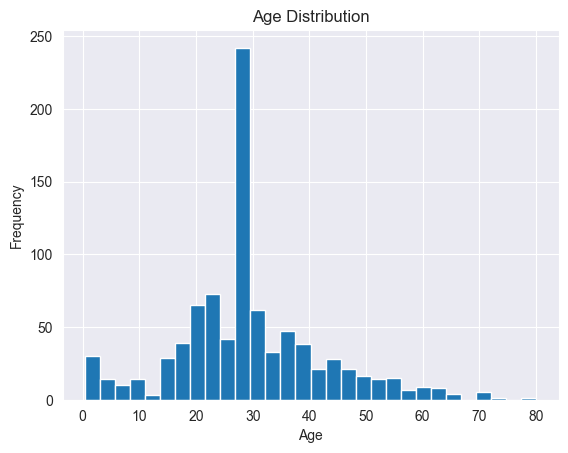

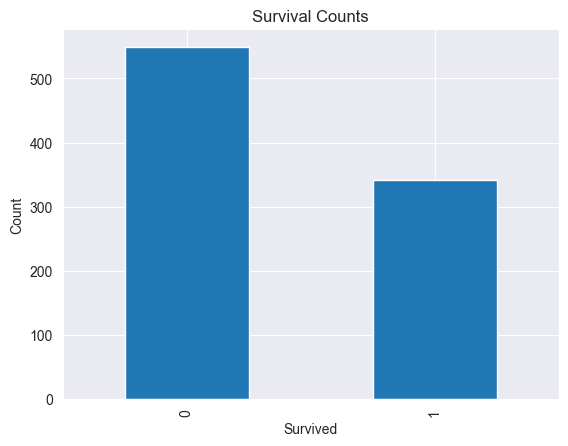

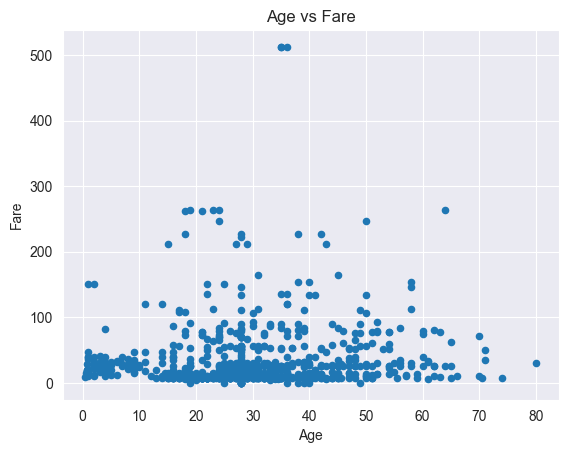

In [5]:
# Histogram of Ages
df['Age'].hist(bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Bar plot of Survived counts
df['Survived'].value_counts().plot(kind='bar')
plt.title('Survival Counts')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

# Scatter plot of Age vs Fare
df.plot.scatter(x='Age', y='Fare')
plt.title('Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

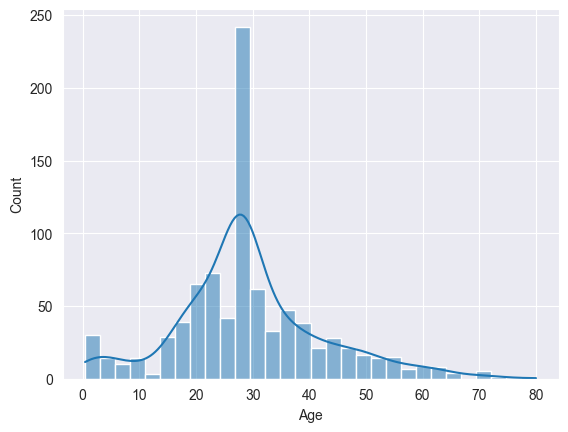

In [6]:
# sns.barplot(x='Sex', y='Fare', data=df)
# sns.histplot(data=df, x='Age', hue='Survived')
sns.histplot(df.Age, kde=True, bins=30)

In [7]:
# df.groupby("Age").describe()
df[(df.Sex == "male") & (df.Survived == 1)].count()

Survived    109
Pclass      109
Sex         109
Age         109
SibSp       109
Parch       109
Fare        109
Embarked    109
dtype: int64

       Sex       Age  Survived
0   female   (0, 12]  0.593750
1   female  (12, 17]  0.826087
2   female  (17, 25]  0.731343
3   female  (25, 35]  0.747899
4   female  (35, 50]  0.732143
5   female  (50, 65]  0.941176
6   female  (65, 80]       NaN
7     male   (0, 12]  0.567568
8     male  (12, 17]  0.095238
9     male  (17, 25]  0.115702
10    male  (25, 35]  0.181102
11    male  (35, 50]  0.206186
12    male  (50, 65]  0.128205
13    male  (65, 80]  0.125000


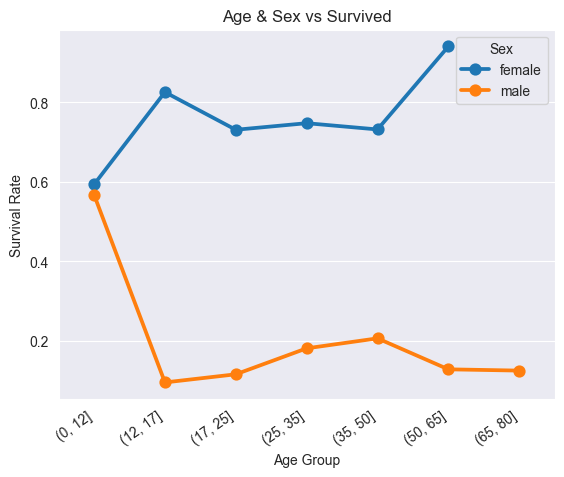

In [8]:
group = df.groupby(["Sex", pd.cut(df['Age'], [0, 12, 17, 25, 35, 50, 65, 80])],
                   observed=False).Survived.mean().reset_index()
print(group)
sns.pointplot(x="Age", y="Survived", hue="Sex", data=group)
plt.title("Age & Sex vs Survived")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.xticks(rotation=35, ha="right")
plt.show()

In [9]:
df[["Sex", "Age", "Survived"]].groupby(['Sex', 'Survived']).describe()

Age                                                    
                 count       mean        std   min   25%   50%   75%   max
Sex    Survived                                                           
female 0          81.0  25.666667  12.145730  2.00  18.0  28.0  30.0  57.0
       1         233.0  28.716738  13.032565  0.75  22.0  28.0  35.0  63.0
male   0         468.0  30.783120  12.418103  1.00  24.0  28.0  36.0  74.0
       1         109.0  27.382294  15.235418  0.42  20.0  28.0  35.0  80.0

Fare
(0, 50]       0.324022
(50, 100]     0.654206
(100, 150]    0.791667
(150, 200]    0.666667
(200, 250]    0.636364
(250, 300]    0.666667
(500, 550]    1.000000
Name: Survived, dtype: float64


(array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.]),
 [Text(-1.0, 0, '(500, 550]'),
  Text(0.0, 0, '(0, 50]'),
  Text(1.0, 0, '(50, 100]'),
  Text(2.0, 0, '(100, 150]'),
  Text(3.0, 0, '(150, 200]'),
  Text(4.0, 0, '(200, 250]'),
  Text(5.0, 0, '(250, 300]'),
  Text(6.0, 0, '(500, 550]'),
  Text(7.0, 0, '')])

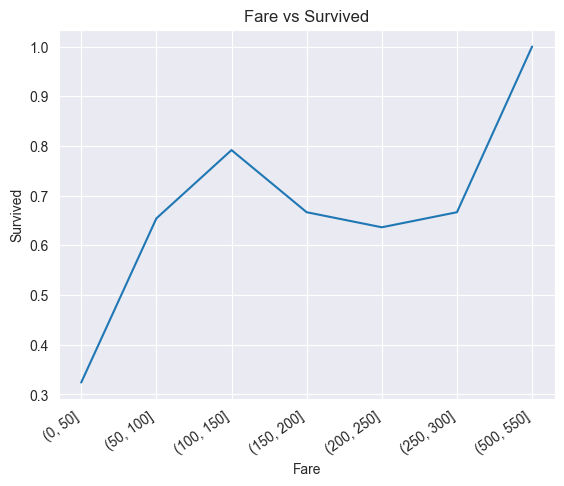

In [10]:
fare_survived = df.groupby(pd.cut(df['Fare'], range(0, 601, 50)), observed=True)["Survived"].mean(numeric_only=True)
print(fare_survived)
fare_survived.plot()
plt.title("Fare vs Survived")
plt.xlabel("Fare")
plt.ylabel("Survived")
plt.xticks(rotation=35, ha="right")

<Axes: xlabel='Age'>

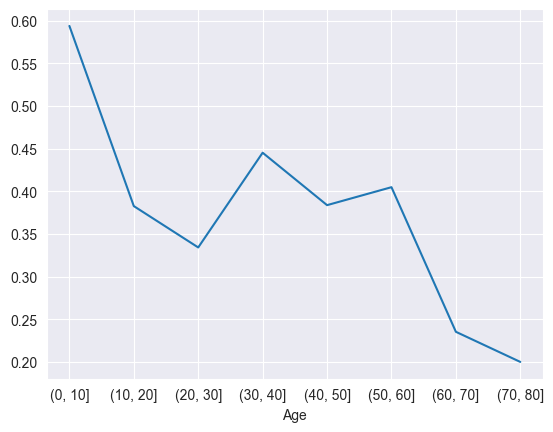

In [11]:
age_survived = df.groupby(pd.cut(df['Age'], range(0, 81, 10)), observed=True)["Survived"].mean()
age_survived.plot()

Fare        Age     
(0, 50]     (0, 10]     0.590164
            (10, 20]    0.326531
            (20, 30]    0.294118
            (30, 40]    0.327434
            (40, 50]    0.295082
            (50, 60]    0.230769
            (60, 70]    0.166667
            (70, 80]    0.200000
(50, 100]   (0, 10]     1.000000
            (10, 20]    0.714286
            (20, 30]    0.595238
            (30, 40]    0.791667
            (40, 50]    0.562500
            (50, 60]    0.692308
            (60, 70]    0.500000
(100, 150]  (10, 20]    0.800000
            (20, 30]    0.833333
            (30, 40]    1.000000
            (40, 50]    0.500000
            (50, 60]    0.500000
(150, 200]  (0, 10]     0.500000
            (20, 30]    0.500000
            (30, 40]    0.666667
            (40, 50]    1.000000
            (50, 60]    1.000000
(200, 250]  (10, 20]    1.000000
            (20, 30]    0.200000
            (30, 40]    1.000000
            (40, 50]    1.000000
(250, 300]  (10, 20]  

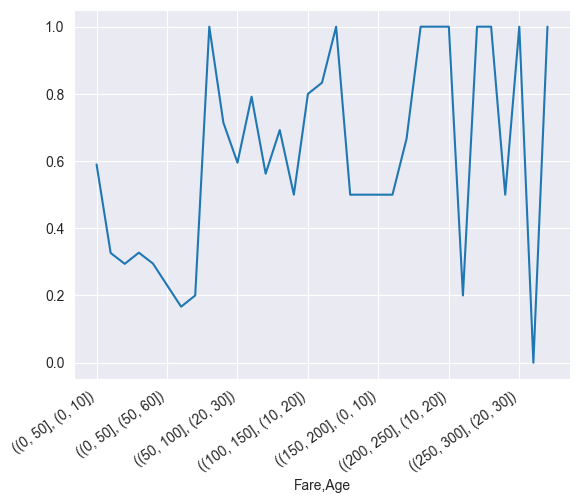

In [12]:
age_fare = df.groupby([pd.cut(df['Fare'], range(0, 601, 50)), pd.cut(df['Age'], range(0, 81, 10))], observed=True)[
    "Survived"].mean(numeric_only=True)
age_fare.plot()
plt.xticks(rotation=35, ha="right")
age_fare

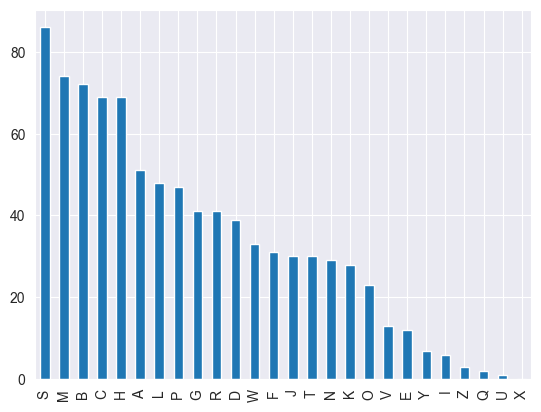

In [13]:
d = {}
for i in range(26):
    letter = chr(ord("A") + i)
    d[letter] = len(df[df.index.str.contains(f"^{letter}".format(letter))].index)
k = pd.Series(d).sort_values(ascending=False)

# Plotting with more ticks
ax = k.plot(kind="bar")

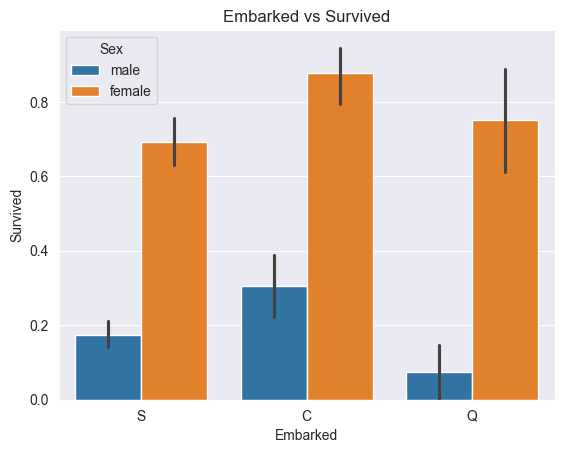

In [14]:
sns.barplot(df, x="Embarked", y="Survived", hue="Sex")
plt.title("Embarked vs Survived")
plt.xlabel("Embarked")
plt.ylabel("Survived")
plt.show()


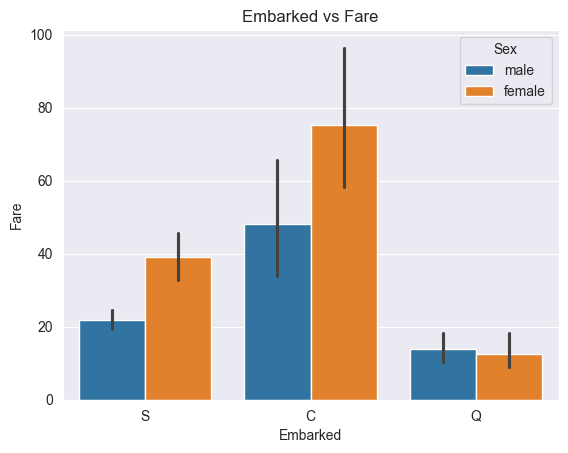

In [15]:
sns.barplot(df, x="Embarked", y="Fare", hue="Sex")
plt.title("Embarked vs Fare")
plt.xlabel("Embarked")
plt.ylabel("Fare")
plt.show()

In [16]:
#exc 6
path2 = "C:\\Users\\merda\\Downloads\\titanic.csv"
data = pd.read_csv("titanic.csv")
# clean data
data.Age = data.Age.fillna(df.Age.median())
data.Embarked = data.Embarked.fillna(df.Embarked.mode()[0])
teenagers = data[["Name", "Ticket", "Age", "Pclass"]].query("Pclass == 1 & 13 <= Age <= 17")
teenagers[["Name", "Ticket"]]

,Name,Ticket
307,"Penasco y Castellana, Mrs. Victor de Satode (M...",PC 17758
329,"Hippach, Miss. Jean Gertrude",111361
435,"Carter, Miss. Lucile Polk",113760
504,"Maioni, Miss. Roberta",110152
550,"Thayer, Mr. John Borland Jr",17421
689,"Madill, Miss. Georgette Alexandra",24160
781,"Dick, Mrs. Albert Adrian (Vera Gillespie)",17474
853,"Lines, Miss. Mary Conover",PC 17592


In [17]:
df = df.replace(["female", "male"], [0, 1])
df.head()

C:\Users\merda\AppData\Local\Temp\ipykernel_9636\3075716856.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(["female", "male"], [0, 1])


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Name,,,,,,,,
"Braund, Mr. Owen Harris",0,3,1,22.0,1,0,7.2500,S
"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",1,1,0,38.0,1,0,71.2833,C
"Heikkinen, Miss. Laina",1,3,0,26.0,0,0,7.9250,S
"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,1,0,35.0,1,0,53.1000,S
"Allen, Mr. William Henry",0,3,1,35.0,0,0,8.0500,S


In [18]:
unique_values = {}
for col in df.columns:
    unique_values[col] = len(df[col].unique())
print(unique_values)

{'Survived': 2, 'Pclass': 3, 'Sex': 2, 'Age': 88, 'SibSp': 7, 'Parch': 7, 'Fare': 248, 'Embarked': 3}
